<font color=#85C1E9 size=8>**Predictive Model for Chagas Disease**

<font color=#858FE9 size=5>**MALDI-TOF · Machine Learning · Confusion Matrices · ROC Curves · Graph ML PoC**

<font color=#AD85E9 size=3>**Yenny Velandia**

In [1]:
#import sys
#!{sys.executable} -m pip install xgboost openpyxl networkx -q
#Only do it once before running thi Notebook for the very 1st time

---
## 1. Paths

In [1]:
import os

SPECTRA_DIR  = r'../chagas/chagas/all spectra'
CLASSIF_FILE = r'../chagas/chagas/clasificacion.xlsx'
OUTPUT_DIR   = '.'

'This is a confirmation if this notebook finds the data'

print('Spectra dir  :', os.path.isdir(SPECTRA_DIR))
print('Labels file  :', os.path.isfile(CLASSIF_FILE))

Spectra dir  : True
Labels file  : True



##  2. Imports

These are the libraries that we will be using for this project:

In [2]:
import glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['font.family'] = 'Times New Roman'
%matplotlib inline

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV

from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    f1_score, cohen_kappa_score, roc_curve, auc
)

import networkx as nx
import joblib

## 3. Loading Data

In [3]:
files = sorted(glob.glob(os.path.join(SPECTRA_DIR, '*.txt')))
print(f'Found {len(files)} spectra')

all_spectra = pd.DataFrame()
for f in files:
    df = pd.read_csv(f, header=None, delimiter=' ')
    all_spectra = pd.concat([all_spectra, df], axis=1)

all_spectra.columns = range(all_spectra.shape[1])

N_POINTS = 23040 #this is just the amount of values the spectra has
Dsna    = all_spectra.iloc[:N_POINTS, 0].reset_index(drop=True)
Dataint = all_spectra.iloc[:N_POINTS, 1::2].copy()
Dataint.columns = range(Dataint.shape[1])

C       = pd.read_excel(CLASSIF_FILE)
Y1      = C[['clasification']].rename(columns={'clasification': 'Clase'})
encoder = OrdinalEncoder(categories=[['A', 'N', 'S']])
y       = encoder.fit_transform(Y1[['Clase']]).ravel().astype(int)

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(Dataint)
X        = x_scaled.T

CLASS_LABELS = ['A', 'N', 'S']
CLASS_COLORS = {'A': '#90EE90', 'N': '#AEC6E8', 'S': '#B39DDB'}  # green, blue, purple

print(f'X: {X.shape} | Classes: {dict(zip(*np.unique(y, return_counts=True)))}')

Found 236 spectra
X: (236, 23040) | Classes: {np.int64(0): np.int64(66), np.int64(1): np.int64(62), np.int64(2): np.int64(108)}


## 4. Train/Test Split

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=42, shuffle=True)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

print(f'Train: {len(x_train)}: 80 % samples')
print(f'Test : {len(x_test)}: 20% samples') 

Train: 188: 80 % samples
Test : 48: 20% samples


## 5. Confusion Matrix Function def.

In [6]:
results       = {}
trained_models = {}

DIAG_COLORS = ['#90EE90', '#AEC6E8', '#B39DDB']  # A=green, N=blue, S=purple

def plot_cm(cm, class_labels, title, filepath):
    """Confusion matrix identical to original notebook style."""
    n   = len(class_labels)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.set_xlim(0, n)
    ax.set_ylim(0, n)

    for i in range(n):
        for j in range(n):
            # i = row (true), j = col (predicted)
            # imshow convention: row 0 is top → invert y
            row = n - 1 - i
            color = DIAG_COLORS[i] if i == j else 'white'
            rect  = mpatches.FancyBboxPatch(
                [j, row], 1, 1,
                boxstyle='square,pad=0',
                facecolor=color, edgecolor='black', linewidth=1.2
            )
            ax.add_patch(rect)
            val = cm[i, j]
            txt_color = 'black'
            if val > 0:
                ax.text(j + 0.5, row + 0.5, str(val),
                        ha='center', va='center',
                        fontsize=17, fontweight='bold', color=txt_color)
            else:
                ax.text(j + 0.5, row + 0.5, '0',
                        ha='center', va='center',
                        fontsize=14, color='#cccccc')

    # Tick labels — side (y) and bottom (x) like original
    ax.set_xticks([j + 0.5 for j in range(n)])
    ax.set_xticklabels(class_labels, fontsize=12)
    ax.set_yticks([i + 0.5 for i in range(n)])
    ax.set_yticklabels(class_labels[::-1], fontsize=12)

    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('True Class', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches='tight')
    plt.show()


def evaluate(name, model, x_tr=x_train, y_tr=y_train,
             x_te=x_test,  y_te=y_test,
             class_labels=CLASS_LABELS):
    model.fit(x_tr, y_tr)
    y_pred = model.predict(x_te)
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, average='weighted')
    kap = cohen_kappa_score(y_te, y_pred)

    print(f'\n{"="*52}\n  {name}\n{"="*52}')
    print(f'  Accuracy : {100*acc:.2f}%  |  F1: {f1:.4f}  |  κ: {kap:.4f}')
    print(classification_report(y_te, y_pred, target_names=class_labels, digits=4))

    cm    = confusion_matrix(y_te, y_pred)
    fname = os.path.join(OUTPUT_DIR, f'CM_{name.replace(" ","_")}.png')
    plot_cm(cm, class_labels, f'{name} Confusion Matrix', fname)

    results[name]        = {'Accuracy': acc, 'F1': f1, 'Kappa': kap}
    trained_models[name] = model
    return model, y_pred

## 6. Classifiers

### 6.1 SVC 


  SVC (RBF, C=40)
  Accuracy : 100.00%  |  F1: 1.0000  |  κ: 1.0000
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        13
           N     1.0000    1.0000    1.0000        14
           S     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48



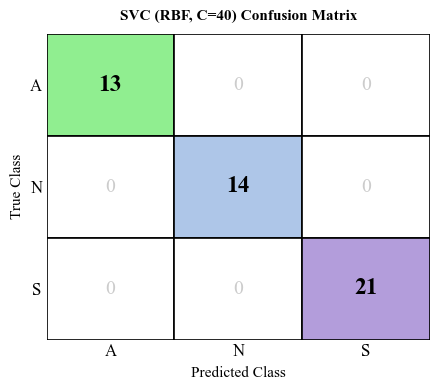

In [7]:
svc_m, _ = evaluate('SVC (RBF, C=40)', SVC(C=40, kernel='rbf', random_state=123))

### 6.2 NuSVC


  NuSVC (nu=0.1)
  Accuracy : 100.00%  |  F1: 1.0000  |  κ: 1.0000
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        13
           N     1.0000    1.0000    1.0000        14
           S     1.0000    1.0000    1.0000        21

    accuracy                         1.0000        48
   macro avg     1.0000    1.0000    1.0000        48
weighted avg     1.0000    1.0000    1.0000        48



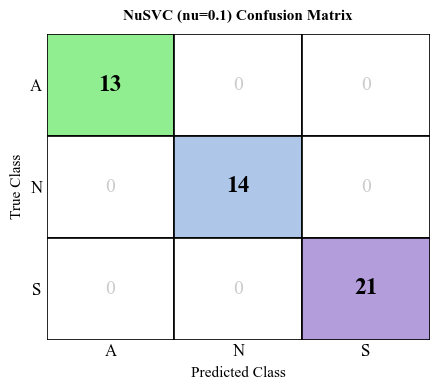

In [8]:
nusvc_m, _ = evaluate('NuSVC (nu=0.1)', NuSVC(nu=0.1, gamma='auto'))

### 6.3 LinearSVC


  LinearSVC
  Accuracy : 97.92%  |  F1: 0.9790  |  κ: 0.9678
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000        13
           N     1.0000    0.9286    0.9630        14
           S     0.9545    1.0000    0.9767        21

    accuracy                         0.9792        48
   macro avg     0.9848    0.9762    0.9799        48
weighted avg     0.9801    0.9792    0.9790        48



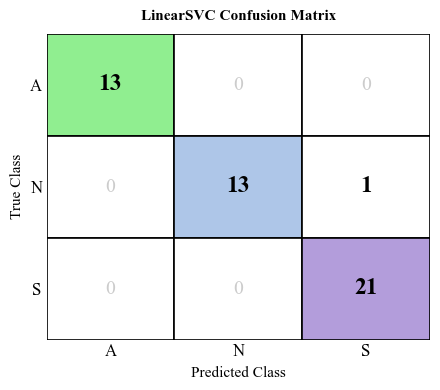

In [9]:
lsvc_m, _ = evaluate('LinearSVC', LinearSVC(max_iter=5000))

### 6.4 MLP: Neural Network


  MLP Neural Network
  Accuracy : 89.58%  |  F1: 0.8964  |  κ: 0.8397
              precision    recall  f1-score   support

           A     0.9167    0.8462    0.8800        13
           N     0.8000    0.8571    0.8276        14
           S     0.9524    0.9524    0.9524        21

    accuracy                         0.8958        48
   macro avg     0.8897    0.8852    0.8867        48
weighted avg     0.8983    0.8958    0.8964        48



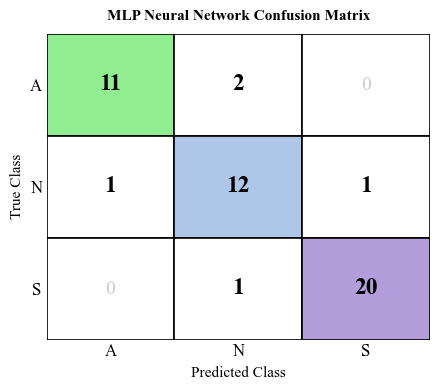

In [10]:
ann_m, _ = evaluate('MLP Neural Network',
    MLPClassifier(hidden_layer_sizes=(20,20), learning_rate_init=0.01,
                  solver='lbfgs', max_iter=5000, random_state=123))

### 6.5 Random Forest


  Random Forest
  Accuracy : 93.75%  |  F1: 0.9369  |  κ: 0.9029
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9231    0.8571    0.8889        14
           S     0.9130    1.0000    0.9545        21

    accuracy                         0.9375        48
   macro avg     0.9454    0.9267    0.9345        48
weighted avg     0.9395    0.9375    0.9369        48



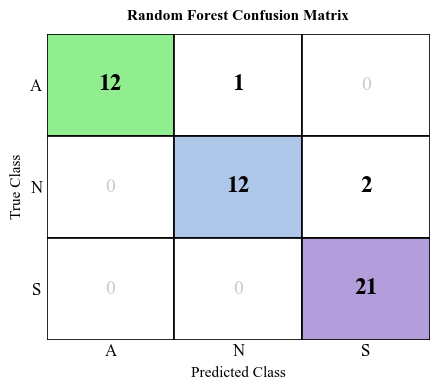

In [11]:
rf_m, _ = evaluate('Random Forest', RandomForestClassifier(random_state=90))

### 6.6 XGBoost


  XGBoost
  Accuracy : 91.67%  |  F1: 0.9162  |  κ: 0.8712
              precision    recall  f1-score   support

           A     0.9231    0.9231    0.9231        13
           N     0.9231    0.8571    0.8889        14
           S     0.9091    0.9524    0.9302        21

    accuracy                         0.9167        48
   macro avg     0.9184    0.9109    0.9141        48
weighted avg     0.9170    0.9167    0.9162        48



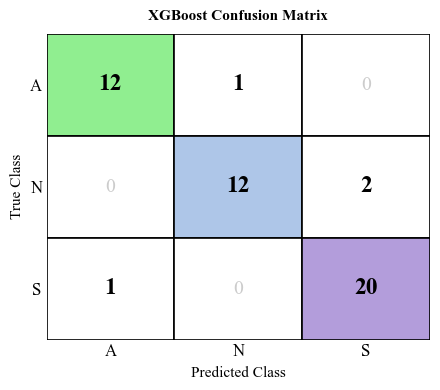

In [12]:
xgb_m, _ = evaluate('XGBoost',
    XGBClassifier(random_state=200, eval_metric='mlogloss', verbosity=0))

### 6.7 SGD


  SGD Classifier
  Accuracy : 91.67%  |  F1: 0.9132  |  κ: 0.8715
              precision    recall  f1-score   support

           A     0.8125    1.0000    0.8966        13
           N     1.0000    0.7143    0.8333        14
           S     0.9545    1.0000    0.9767        21

    accuracy                         0.9167        48
   macro avg     0.9223    0.9048    0.9022        48
weighted avg     0.9293    0.9167    0.9132        48



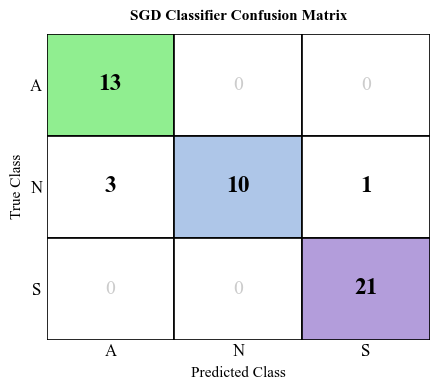

In [13]:
sgd_m, _ = evaluate('SGD Classifier', SGDClassifier(max_iter=100, tol=1e-3, random_state=42))

### 6.8 KNN


  KNN
  Accuracy : 83.33%  |  F1: 0.8333  |  κ: 0.7437
              precision    recall  f1-score   support

           A     0.7692    0.7692    0.7692        13
           N     0.7857    0.7857    0.7857        14
           S     0.9048    0.9048    0.9048        21

    accuracy                         0.8333        48
   macro avg     0.8199    0.8199    0.8199        48
weighted avg     0.8333    0.8333    0.8333        48



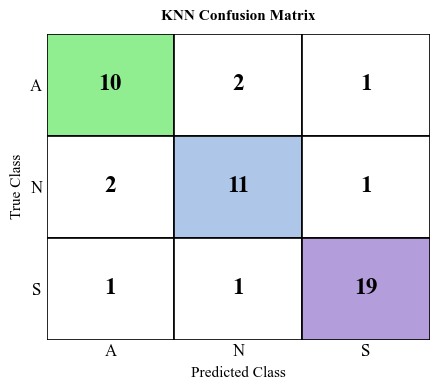

In [14]:
knn_m, _ = evaluate('KNN', KNeighborsClassifier())

### 6.9 Logistic Regression


  Logistic Regression
  Accuracy : 95.83%  |  F1: 0.9582  |  κ: 0.9356
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9286    0.9286    0.9286        14
           S     0.9545    1.0000    0.9767        21

    accuracy                         0.9583        48
   macro avg     0.9610    0.9505    0.9551        48
weighted avg     0.9593    0.9583    0.9582        48



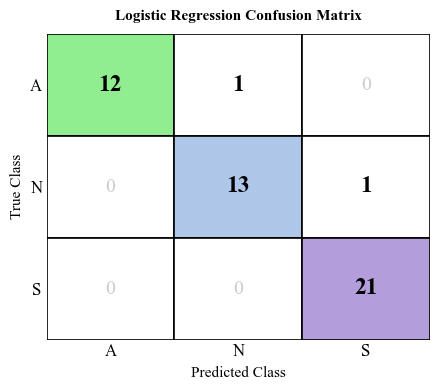

In [15]:
lr_m, _ = evaluate('Logistic Regression', LogisticRegression(solver='lbfgs', max_iter=1000))

### 6.10 Bagging


  Bagging Classifier
  Accuracy : 91.67%  |  F1: 0.9159  |  κ: 0.8719
              precision    recall  f1-score   support

           A     0.9286    1.0000    0.9630        13
           N     0.9231    0.8571    0.8889        14
           S     0.9048    0.9048    0.9048        21

    accuracy                         0.9167        48
   macro avg     0.9188    0.9206    0.9189        48
weighted avg     0.9166    0.9167    0.9159        48



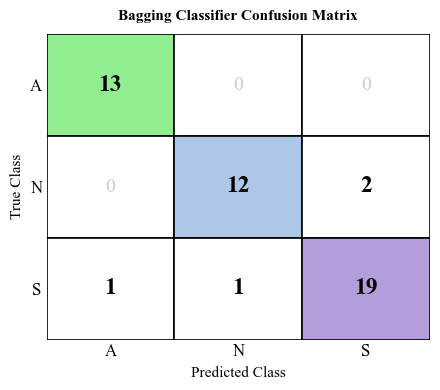

In [16]:
bag_m, _ = evaluate('Bagging Classifier', BaggingClassifier(random_state=42))

### 6.11 ExtraTrees


  ExtraTrees
  Accuracy : 93.75%  |  F1: 0.9369  |  κ: 0.9029
              precision    recall  f1-score   support

           A     1.0000    0.9231    0.9600        13
           N     0.9231    0.8571    0.8889        14
           S     0.9130    1.0000    0.9545        21

    accuracy                         0.9375        48
   macro avg     0.9454    0.9267    0.9345        48
weighted avg     0.9395    0.9375    0.9369        48



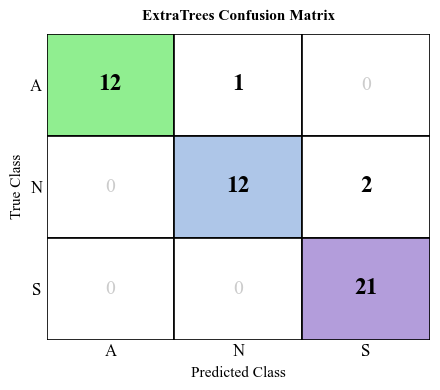

In [17]:
et_m, _ = evaluate('ExtraTrees', ExtraTreesClassifier(n_estimators=300, random_state=42))

## 7. Model Comparison Table

In [18]:
res_df = pd.DataFrame(results).T
res_df['Accuracy (%)'] = (res_df['Accuracy']*100).round(2)
res_df = res_df.sort_values('Accuracy', ascending=False)
print(res_df[['Accuracy (%)', 'F1', 'Kappa']].to_string())

                     Accuracy (%)        F1     Kappa
SVC (RBF, C=40)            100.00  1.000000  1.000000
NuSVC (nu=0.1)             100.00  1.000000  1.000000
LinearSVC                   97.92  0.979023  0.967807
Logistic Regression         95.83  0.958159  0.935570
Random Forest               93.75  0.936873  0.902900
ExtraTrees                  93.75  0.936873  0.902900
XGBoost                     91.67  0.916236  0.871227
Bagging Classifier          91.67  0.915895  0.871915
SGD Classifier              91.67  0.913197  0.871486
MLP Neural Network          89.58  0.896379  0.839679
KNN                         83.33  0.833333  0.743658


## 8. ROC Curves
One curve per class (A, N, S) for all 11 models.  
LinearSVC and SGDClassifier use **CalibratedClassifierCV** to get probabilities

In [26]:
# Models with native predict_proba
ROC_MODELS = {
    'SVC (RBF, C=40)'    : SVC(C=40, kernel='rbf', random_state=123, probability=True),
    'NuSVC (nu=0.1)'     : NuSVC(nu=0.1, gamma='auto', probability=True),
    'LinearSVC'          : CalibratedClassifierCV(LinearSVC(max_iter=5000)),  # calibrated
    'MLP Neural Network' : MLPClassifier(hidden_layer_sizes=(20,20),
                                         learning_rate_init=0.01, solver='lbfgs',
                                         max_iter=5000, random_state=123),
    'Random Forest'      : RandomForestClassifier(random_state=90),
    'XGBoost'            : XGBClassifier(random_state=200, eval_metric='mlogloss', verbosity=0),
    'SGD Classifier'     : CalibratedClassifierCV(SGDClassifier(max_iter=100, tol=1e-3, random_state=42)),
    'KNN'                : KNeighborsClassifier(),
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000),
    'Bagging Classifier' : BaggingClassifier(random_state=42),
    'ExtraTrees'         : ExtraTreesClassifier(n_estimators=300, random_state=42),
}

CLASS_ROC_COLORS = ['#E74C3C', '#2ECC71', '#3498DB']  # A, N, S

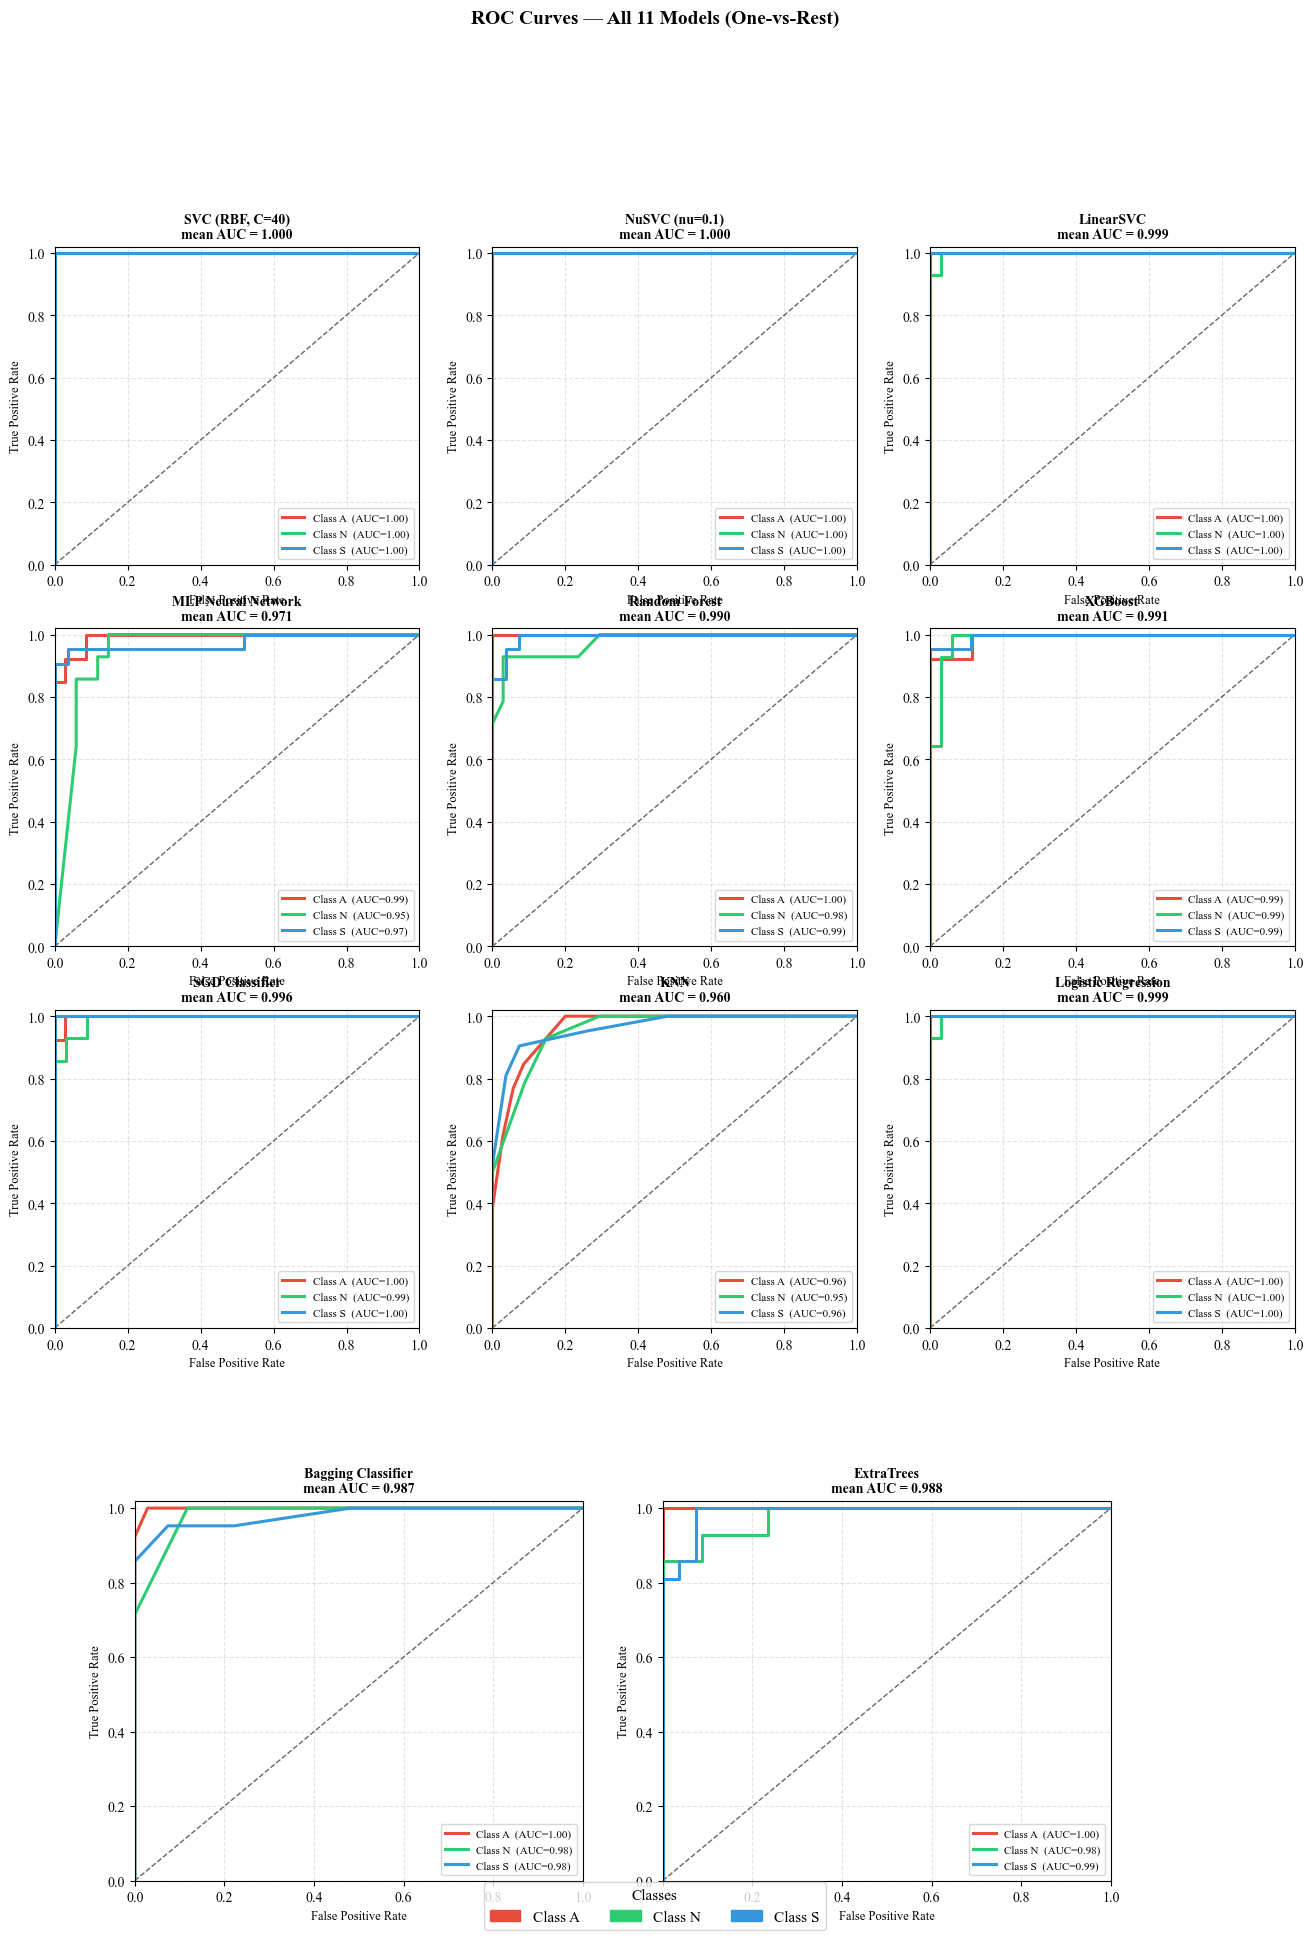

Saved → .\ROC_all_11_models.png


In [20]:
model_names = list(ROC_MODELS.keys())

# Layout: rows of 3, 3, 3, 2  →  use 4 rows × 3 cols, hide last cell
ROWS, COLS = 4, 3
fig, axes = plt.subplots(ROWS, COLS, figsize=(16, 19))

for idx, name in enumerate(model_names):
    row, col = divmod(idx, COLS)
    ax = axes[row][col]

    y_score  = all_scores[name]
    mean_auc = []

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.6)
    for i, label in enumerate(CLASS_LABELS):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        ra           = auc(fpr, tpr)
        mean_auc.append(ra)
        ax.plot(fpr, tpr, color=CLASS_ROC_COLORS[i], lw=2.2,
                label=f'Class {label}  (AUC={ra:.2f})')

    ax.set_title(f'{name}\nmean AUC = {np.mean(mean_auc):.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

# Hide last empty cell (row 3, col 2)
axes[3][2].set_visible(False)

# Center the last two plots (row 3)
# Shift col0 and col1 of row3 to be centered
for col_idx in [0, 1]:
    axes[3][col_idx].set_position(
        [0.175 + col_idx * 0.33, 0.02, 0.28, 0.20]
    )

plt.suptitle('ROC Curves — All 11 Models (One-vs-Rest)',
             fontsize=14, fontweight='bold', y=1.005)

# Global legend for classes
patches = [mpatches.Patch(color=CLASS_ROC_COLORS[i], label=f'Class {l}')
           for i, l in enumerate(CLASS_LABELS)]
fig.legend(handles=patches, loc='lower center', ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.01),
           title='Classes', title_fontsize=11)

fpath = os.path.join(OUTPUT_DIR, 'ROC_all_11_models.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fpath}')

## 9. Graph Machine Learning (Graph ML PoC)

Una **Proof of Concept en Graph ML** modela las muestras como **nodos** en un grafo  
y conecta con **aristas** aquellos pares de muestras que son más similares entre sí  
(vecinos más cercanos en el espacio de PCA).  

La hipótesis es que muestras de la misma clase (A, N, S) deben formar **clusters conectados**,  
lo que valida que la estructura de similitud proteómica respalda la clasificación clínica.

In [21]:
# ── Step 1: Reduce to 10 PCA components ─────────────────────────────────────
pca    = PCA(n_components=10, random_state=42)
X_pca  = pca.fit_transform(X)   # shape: (n_samples, 10)

# ── Step 2: Build KNN graph (k=5 neighbors per node) ─────────────────────────
from sklearn.neighbors import kneighbors_graph
K = 5
A = kneighbors_graph(X_pca, n_neighbors=K, mode='connectivity', include_self=False)

G = nx.from_scipy_sparse_array(A)

# Assign class label as node attribute
for node in G.nodes():
    G.nodes[node]['class'] = int(y[node])

print(f'Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

# Edge stats: how many edges connect same class vs different class?
intra, inter = 0, 0
for u, v in G.edges():
    if G.nodes[u]['class'] == G.nodes[v]['class']:
        intra += 1
    else:
        inter += 1
total = intra + inter
print(f'Intra-class edges : {intra} ({100*intra/total:.1f}%)')
print(f'Inter-class edges : {inter} ({100*inter/total:.1f}%)')
print(f'→ {100*intra/total:.1f}% of KNN connections link samples of the same class')

Graph: 236 nodes, 780 edges
Intra-class edges : 581 (74.5%)
Inter-class edges : 199 (25.5%)
→ 74.5% of KNN connections link samples of the same class


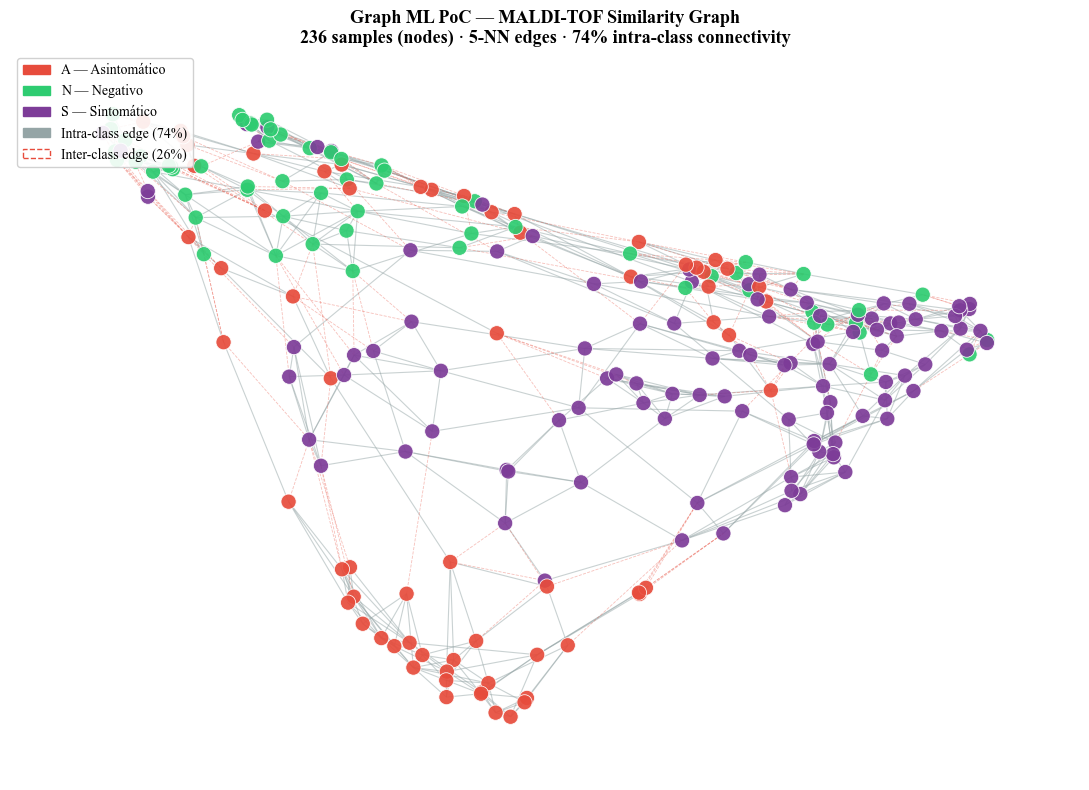

Saved → .\GraphML_PoC_similarity_graph.png


In [22]:
# ── Step 3: Visualize the graph ───────────────────────────────────────────────
NODE_COLORS_MAP = {0: '#E74C3C', 1: '#2ECC71', 2: '#7D3C98'}  # A=red, N=green, S=purple
node_colors = [NODE_COLORS_MAP[G.nodes[n]['class']] for n in G.nodes()]

# Layout: spring layout on PCA-2D positions for reproducibility
pos_init = {i: (X_pca[i, 0], X_pca[i, 1]) for i in range(len(y))}
pos = nx.spring_layout(G, pos=pos_init, seed=42, k=0.4, iterations=60)

fig, ax = plt.subplots(figsize=(11, 8))

# Draw edges — color by intra/inter class
intra_edges = [(u, v) for u, v in G.edges() if G.nodes[u]['class'] == G.nodes[v]['class']]
inter_edges = [(u, v) for u, v in G.edges() if G.nodes[u]['class'] != G.nodes[v]['class']]

nx.draw_networkx_edges(G, pos, edgelist=intra_edges,
                       edge_color='#95A5A6', alpha=0.5, width=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=inter_edges,
                       edge_color='#E74C3C', alpha=0.35, width=0.6,
                       style='dashed', ax=ax)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                       node_size=120, alpha=0.92,
                       edgecolors='white', linewidths=0.6, ax=ax)

# Legend
legend_patches = [
    mpatches.Patch(color='#E74C3C', label='A — Asintomático'),
    mpatches.Patch(color='#2ECC71', label='N — Negativo'),
    mpatches.Patch(color='#7D3C98', label='S — Sintomático'),
    mpatches.Patch(color='#95A5A6', label=f'Intra-class edge ({100*intra/total:.0f}%)'),
    mpatches.Patch(color='#E74C3C', label=f'Inter-class edge ({100*inter/total:.0f}%)',
                   linestyle='dashed', fill=False),
]
ax.legend(handles=legend_patches, loc='upper left', fontsize=10,
          framealpha=0.9)

ax.set_title(
    f'Graph ML PoC — MALDI-TOF Similarity Graph\n'
    f'{G.number_of_nodes()} samples (nodes) · {K}-NN edges · '
    f'{100*intra/total:.0f}% intra-class connectivity',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR, 'GraphML_PoC_similarity_graph.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fpath}')

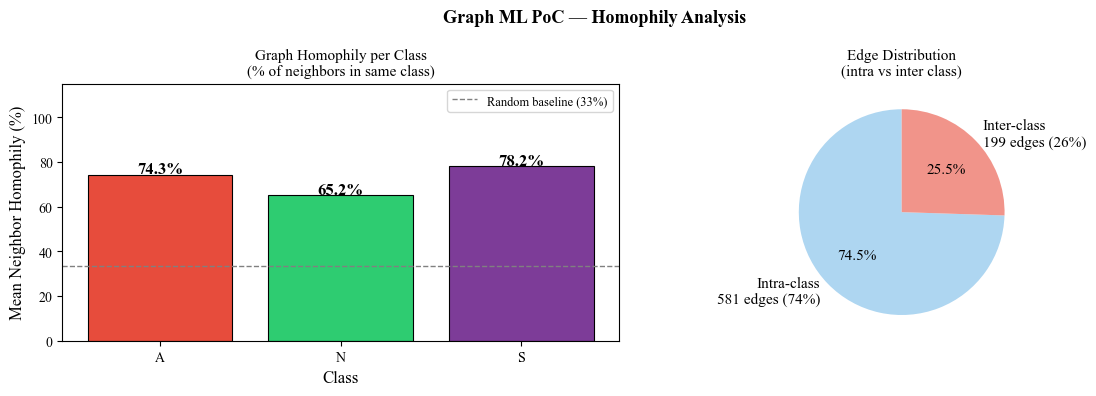

Saved → .\GraphML_PoC_homophily.png


In [23]:
# ── Step 4: Edge homophily bar chart ─────────────────────────────────────────
# Homophily per class: what fraction of a node's neighbors share its class?
homophily = {0: [], 1: [], 2: []}
for node in G.nodes():
    c     = G.nodes[node]['class']
    nbrs  = list(G.neighbors(node))
    if nbrs:
        same  = sum(1 for nb in nbrs if G.nodes[nb]['class'] == c)
        homophily[c].append(same / len(nbrs))

mean_homo = {CLASS_LABELS[k]: np.mean(v)*100 for k, v in homophily.items()}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar: mean homophily per class
bars = axes[0].bar(mean_homo.keys(), mean_homo.values(),
                   color=['#E74C3C', '#2ECC71', '#7D3C98'],
                   edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, mean_homo.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 115)
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Mean Neighbor Homophily (%)', fontsize=12)
axes[0].set_title('Graph Homophily per Class\n(% of neighbors in same class)', fontsize=11)
axes[0].axhline(100/3, color='gray', linestyle='--', lw=1, label='Random baseline (33%)')
axes[0].legend(fontsize=9)

# Pie: intra vs inter edges
axes[1].pie([intra, inter],
            labels=[f'Intra-class\n{intra} edges ({100*intra/total:.0f}%)',
                    f'Inter-class\n{inter} edges ({100*inter/total:.0f}%)'],
            colors=['#AED6F1', '#F1948A'],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title('Edge Distribution\n(intra vs inter class)', fontsize=11)

plt.suptitle('Graph ML PoC — Homophily Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
fpath = os.path.join(OUTPUT_DIR, 'GraphML_PoC_homophily.png')
plt.savefig(fpath, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fpath}')

In [24]:
# ── Step 5: PoC Summary text ──────────────────────────────────────────────────
print('='*60)
print('  Graph ML Proof of Concept — Summary')
print('='*60)
print(f'  Nodes (samples)      : {G.number_of_nodes()}')
print(f'  Edges (KNN, k={K})     : {G.number_of_edges()}')
print(f'  Intra-class edges    : {intra} ({100*intra/total:.1f}%)')
print(f'  Inter-class edges    : {inter} ({100*inter/total:.1f}%)')
print()
for cls, val in mean_homo.items():
    print(f'  Homophily class {cls}   : {val:.1f}%  (random baseline: 33%)')
print()
print('  ✅ High intra-class connectivity validates that MALDI-TOF')
print('     proteomic profiles form separable clusters per class.')
print('  ✅ Graph structure supports the use of Graph Neural Networks')
print('     (GNN) as a future step to leverage relational information.')
print('='*60)

  Graph ML Proof of Concept — Summary
  Nodes (samples)      : 236
  Edges (KNN, k=5)     : 780
  Intra-class edges    : 581 (74.5%)
  Inter-class edges    : 199 (25.5%)

  Homophily class A   : 74.3%  (random baseline: 33%)
  Homophily class N   : 65.2%  (random baseline: 33%)
  Homophily class S   : 78.2%  (random baseline: 33%)

  ✅ High intra-class connectivity validates that MALDI-TOF
     proteomic profiles form separable clusters per class.
  ✅ Graph structure supports the use of Graph Neural Networks
     (GNN) as a future step to leverage relational information.


## 💾 10. Saving Models

In [25]:
joblib.dump(trained_models.get('SVC (RBF, C=40)'),
            os.path.join(OUTPUT_DIR, 'Mod_chagas_svc.pkl'))
joblib.dump(trained_models.get('MLP Neural Network'),
            os.path.join(OUTPUT_DIR, 'Mod_chagas_ann.pkl'))
print('Models saved ✓')
print(f'\nBest model: {res_df.index[0]}  ({res_df["Accuracy (%)"].iloc[0]:.1f}%)')

Models saved ✓

Best model: SVC (RBF, C=40)  (100.0%)
